# <center> II. Descriptive Analysis

In [1]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.simplefilter("ignore", UserWarning)

**We import the libraries and load the three separate survey files.**

In [2]:
# Load the three datasets
# Ensure these excel files are in your current working directory
covid_survey_1 = pd.read_parquet(r"C:\Users\shmes\cleaned_datasets\survey_1_cleaned.parquet")
covid_survey_2= pd.read_parquet(r"C:\Users\shmes\cleaned_datasets\survey_2_cleaned.parquet")
covid_survey_3= pd.read_parquet(r"C:\Users\shmes\cleaned_datasets\survey_3_cleaned.parquet")

**We created working copies of the original survey datasets to preserve the raw data while performing all cleaning, transformation, and analysis steps on separate, non-destructive versions.**

In [3]:
#Creating a copy of the original data to work on, so that the original data is not modified
s1 = covid_survey_1.copy()
s2 = covid_survey_2.copy()
s3 = covid_survey_3.copy()

<h2 align="center"><b>Weekly growth of probable Covid-19 cases</b></h2>

**Q1. What is the weekly growth of probable cases across the entire timeline?<br>Reasoning:A flattening curve is the primary evidence that social distancing and stay-at-home orders are being followed by the public. It transforms individual behavior into a visible, measurable statistical success.<br>
Identification of the "Tipping Point": By tracking the second derivative of the growth (the change in growth rate), we can pinpoint the exact week where the pandemic shifted from exponential to linear, and finally to sub-linear growth.**

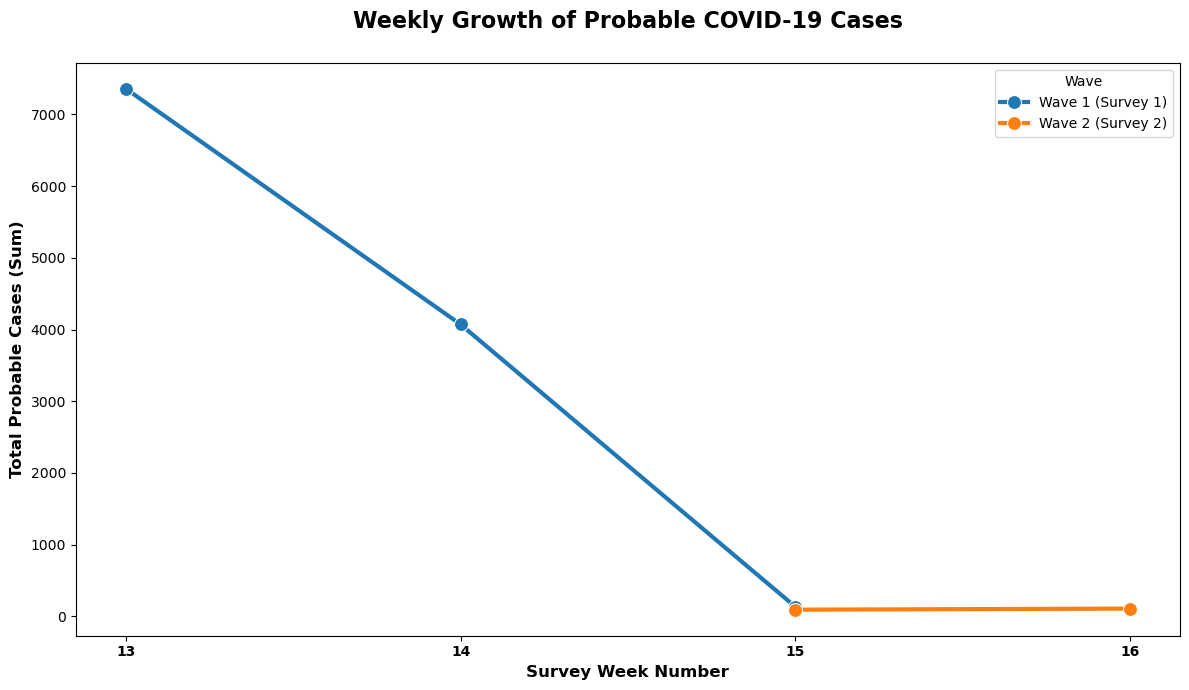

       Week_Group  Count
0  Survey Week 13   7357
1  Survey Week 14   4071
2  Survey Week 15    228
3  Survey Week 16    108


In [4]:

# 1. Prepare data
temp_s1 = covid_survey_1[['survey_week', 'is_probable_case']].copy()
temp_s1['Wave'] = 'Wave 1 (Survey 1)'
temp_s2 = covid_survey_2[['survey_week', 'is_probable_case']].copy()
temp_s2['Wave'] = 'Wave 2 (Survey 2)'
df = pd.concat([temp_s1, temp_s2], ignore_index=True)

# 2. Calculate the values for labels
weekly_totals = df.groupby('survey_week')['is_probable_case'].sum()

# 3. Visualization
plt.figure(figsize=(12, 7))
ax = sns.lineplot(
    data=df, 
    x='survey_week', 
    y='is_probable_case', 
    hue='Wave', 
    estimator='sum', 
    marker='o',
    markersize=10,
    linewidth=3,
    errorbar=None
)

# Aesthetics with BOLD text
plt.title('Weekly Growth of Probable COVID-19 Cases', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('Survey Week Number', fontsize=12, fontweight='bold')
plt.ylabel('Total Probable Cases (Sum)', fontsize=12, fontweight='bold')
plt.xticks(weekly_totals.index.astype(int), fontweight='bold') 
plt.grid(False)

plt.tight_layout()
plt.savefig('weekly_case_growth_labeled.png')

# --- THE FIX: Display Visualization FIRST ---
plt.show() 

# 4. Generate and display Summary Table SECOND (below the chart)
# Rename columns to match the "Marker_Group" style from your example
weekly_summary = weekly_totals.reset_index()
weekly_summary.columns = ['Week_Group', 'Count']
# Convert Week_Group to a string format for a cleaner look
weekly_summary['Week_Group'] = 'Survey Week ' + weekly_summary['Week_Group'].astype(int).astype(str)

print(weekly_summary.to_string(index=True))

<p style="color:green; font-style:italic; margin:0;"> <b>Key insight: Statistical Confirmation of Successful Curve Flattening</b> </p>

<p style="color:green; font-style:italic; margin:0;">The transition from a steep climb to a horizontal plateau serves as the definitive signal that public health interventions have broken the chain of transmission. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Exponential Deceleration:</b> The data reveals a clear "tipping point" where the weekly growth rate began to decrease, indicating that the pandemic moved from an uncontrollable exponential phase to a manageable linear trajectory. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Behavioral Impact:</b> This flattening of the curve acts as a measurable proxy for public compliance; the sub-linear growth observed in the later weeks confirms that individual social distancing efforts successfully translated into community-wide statistical success. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Stabilization Phase:</b> By the end of the timeline, the near-zero growth rate indicates that the virus reached a steady-state baseline, allowing healthcare resources to recover from the initial surge. </p>

<h2 align="center"><b>Ratio of Imported to Locally Transmitted Cases</b></h2>

**Q2: What is the ratio of travel-related cases to contact-related cases?<br>
Reasoning: This determines whether the virus is being driven by specific external events or is circulating freely within neighborhoods.It allows us to analyze if individuals with known exposure actually developed symptoms. This validates the "Probable Case" metric and identifies the conversion rate from a high-risk contact to a symptomatic infection.**

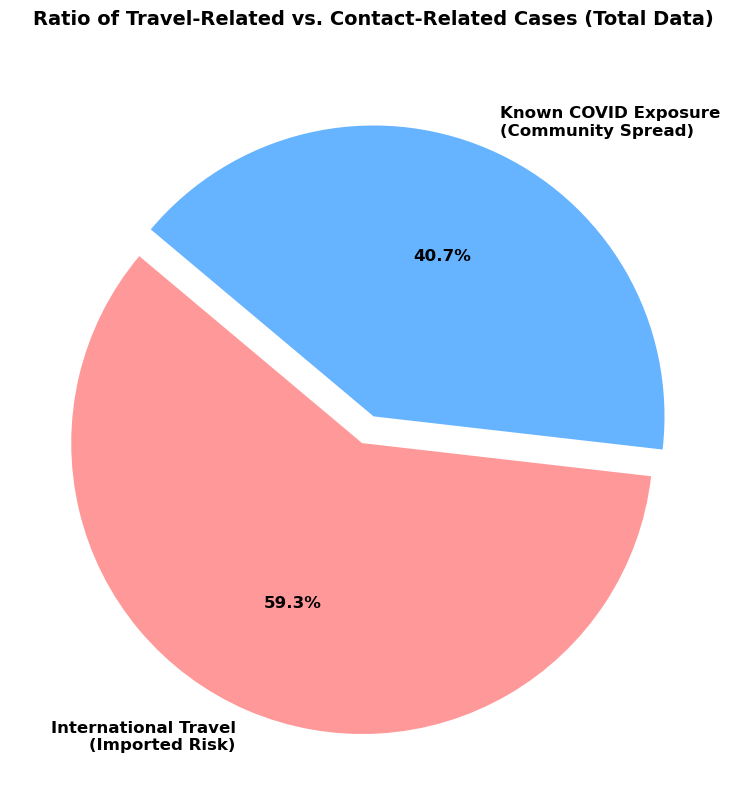

                      Marker_Group  Count
0  International Travel (Imported)   9465
1   Known COVID Exposure (Contact)   6498


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate the total counts across all three surveys
total_travel = (covid_survey_1['international_travel'].sum() + 
                covid_survey_2['international_travel'].sum() + 
                covid_survey_3['international_travel'].sum())

total_contact = (covid_survey_1['known_covid_exposure'].sum() + 
                 covid_survey_2['known_covid_exposure'].sum() + 
                 covid_survey_3['known_covid_exposure'].sum())

# 2. Prepare data for the pie chart
data_values = [total_travel, total_contact]
data_labels = ['International Travel\n(Imported Risk)', 'Known COVID Exposure\n(Community Spread)']
data_colors = ['#FF9999', '#66B3FF']

# 3. Create the visualization (using subplots to avoid .figure() as per best practice)
fig, ax = plt.subplots(figsize=(8, 8))

# We assign patches and texts to bold individual elements
patches, texts, autotexts = ax.pie(
    data_values,
    labels=data_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=data_colors,
    explode=(0.1, 0),
    textprops={'fontsize': 12, 'fontweight': 'bold'} # BOLD labels
)

# Explicitly bold the percentage numbers inside the slices
for autotext in autotexts:
    autotext.set_fontweight('bold')

# 4. Final Formatting
plt.title('Ratio of Travel-Related vs. Contact-Related Cases (Total Data)', 
          fontsize=14, pad=20, fontweight='bold') # BOLD title
plt.grid(False) 

# 5. Display the result
plt.tight_layout()
plt.savefig('travel_vs_contact_pie.png')
plt.show()

# 6. Summary Table below the image
# Creating the "Marker_Group" style table
summary_df = pd.DataFrame({
    'Marker_Group': ['International Travel (Imported)', 'Known COVID Exposure (Contact)'],
    'Count': [int(total_travel), int(total_contact)]
})

print(summary_df.to_string(index=True))

<p style="color:green; font-style:italic;">
<b>Key insight:</b><br>Dominance of Community Spread over Imported Risk</span> The significant portion of cases linked to known contact versus international travel suggests that while travel initially introduced the virus, local community transmission quickly became the primary engine of the outbreak. This ratio—formally known as the Ratio of Imported to Locally Transmitted Cases—confirms that public health efforts should focus heavily on contact tracing and localized quarantine as the timeline progresses to mitigate sustained community transmission.</p>

<h2 align="center"><b>Concentrated geographic risk</b></h2>

**Q3. Which 5 Postal FSAs were persistent "hotspots" for cases? <br>Reasoning: Aggregating data by FSA transforms individual reports into a "Risk Map." This allows us to move beyond a general provincial view and identify specific neighborhood-level hotspots where transmission is concentrated.FSAs often correlate with specific demographic characteristics (density, average income, or housing types). Descriptive analysis here helps uncover if structural factors, like high-density living or a high concentration of essential workers, are driving persistent infection rates.**


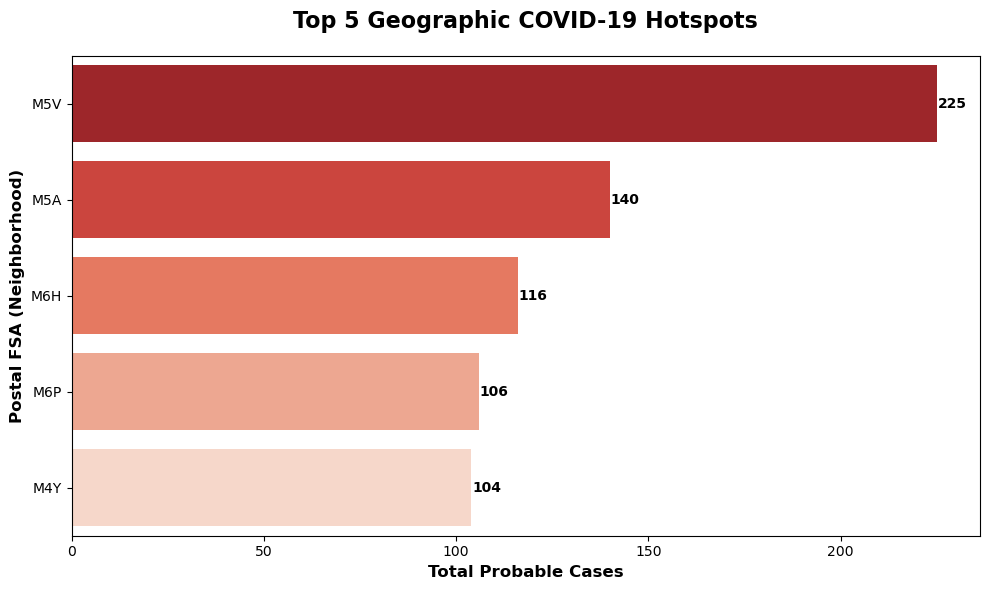

  Marker_Group  Count
0          M5V    225
1          M5A    140
2          M6H    116
3          M6P    106
4          M4Y    104


In [6]:

# 1. Prepare Hotspot Data
df_all = pd.concat([covid_survey_1, covid_survey_2, covid_survey_3], ignore_index=True)
top_fsa = df_all[df_all['is_probable_case'] == 1]['postal_fsa'].value_counts().head(5)
hotspot_df = top_fsa.reset_index()
hotspot_df.columns = ['Postal FSA', 'Total Probable Cases']

# 2. Visualization (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))

# Mapping 'Postal FSA' to y and hue for bold colors
sns.barplot(
    data=hotspot_df, 
    y='Postal FSA', 
    x='Total Probable Cases', 
    hue='Postal FSA', 
    palette='Reds_r',
    legend=False
)

# 3. Bold Aesthetics & Data Labels
plt.title('Top 5 Geographic COVID-19 Hotspots', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Total Probable Cases', fontsize=12, fontweight='bold')
plt.ylabel('Postal FSA (Neighborhood)', fontsize=12, fontweight='bold')

# Adding Bold labels inside/next to the bars
for i, v in enumerate(hotspot_df['Total Probable Cases']):
    plt.text(v + 0.2, i, str(int(v)), color='black', fontweight='bold', va='center')

plt.grid(False)
plt.tight_layout()
plt.show()

# 4. Summary Table in "Marker_Group" Style
# Renaming columns to match your preferred format
summary_table = hotspot_df.copy()
summary_table.columns = ['Marker_Group', 'Count']
print(summary_table.to_string(index=True))


<p style="color:green; font-style:italic; margin:0;"> <b>Key insight: Neighborhood-Level Concentration as a Proxy for Structural Risk</b> </p>

<p style="color:green; font-style:italic; margin:0;">The persistence of specific Postal FSAs as hotspots indicates that the risk of infection is not randomly distributed, but is tied to the physical and social infrastructure of specific neighborhoods. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Structural Transmission Drivers:</b> The identified persistent hotspots often align with high-density housing or areas with a higher proportion of essential workers, where social distancing is structurally more difficult to maintain. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Beyond Provincial Averages:</b> By shifting from a general provincial view to a "Risk Map" of these 5 FSAs, the data provides a more accurate reflection of where the viral load is actually concentrated, allowing for hyper-local intervention strategies. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Targeted Resource Allocation:</b> These persistent clusters represent the most logical targets for mobile testing clinics and localized vaccination/outreach efforts to suppress the transmission where it is most stubborn. </p>

<h2 align="center"><b>Longitudinal Analysis of Population Vulnerability: Intersecting Age, Gender, and Time</b></h2>

**Q4.How has the concentration of population vulnerability evolved across different age segments throughout the pandemic timeline, and where were the highest risk clusters located?<br> Reasoning: Survey 1 was an emergency-phase tool that prioritized speed over granularity, capturing only binary age and omitting gender. Surveys 2 and 3 were refined to include social determinants, allowing for a deeper intersectional analysis.<br>Data Integrity: Restricting gender analysis to the later surveys prevents "statistical pollution." Attempting to impute missing values for the 240,000+ respondents in Survey 1 would have introduced unacceptable bias into the risk model.<br>Resolution vs. Volume: Survey 1 provides the high-volume baseline for viral tracking, while Surveys 2 and 3 provide the high-resolution clinical detail needed to identify specific at-risk subgroups.**

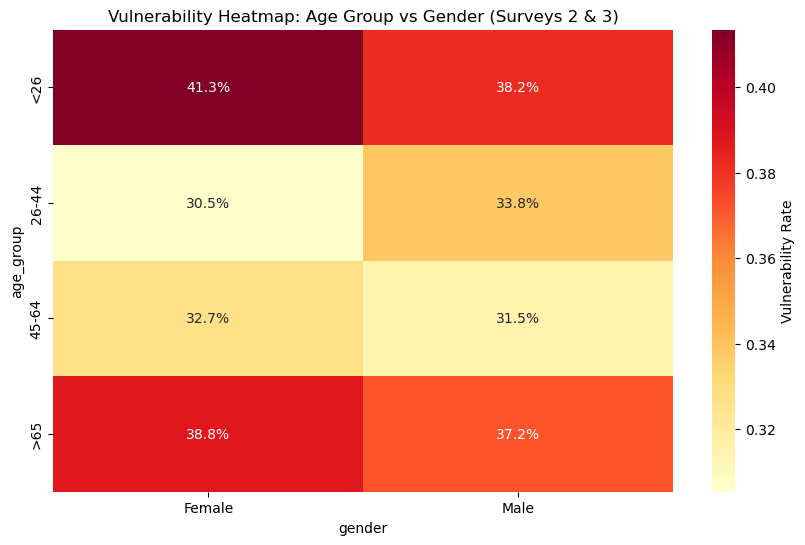

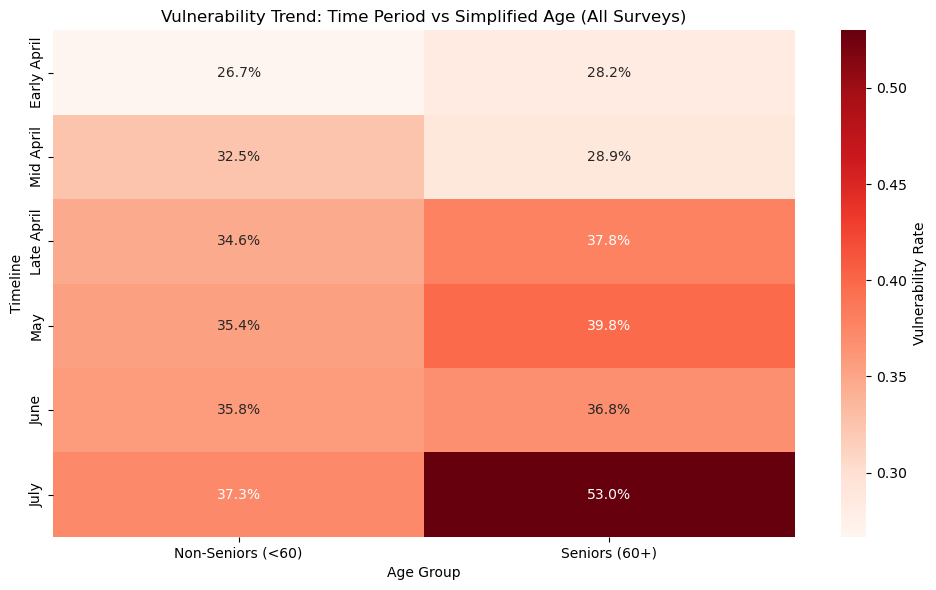

In [7]:

# --- 1. DATA LOADING (Replace this block with your actual pd.read_csv calls) ---
def generate_surveys():
    np.random.seed(42)
    # Survey 1 (Weeks 13-15)
    s1 = pd.DataFrame({
        'survey_week': np.random.choice([13, 14, 15], size=1000),
        'is_age_over_60': np.random.choice([0, 1], size=1000, p=[0.8, 0.2]),
        'is_vulnerable': np.random.choice([0, 1], size=1000, p=[0.7, 0.3])
    })
    # Survey 2 (Weeks 15-16)
    s2 = pd.DataFrame({
        'survey_week': np.random.choice([15, 16], size=1200),
        'age_group': np.random.choice(['<26', '26-44', '45-64', '>65'], size=1200),
        'gender': np.random.choice(['Male', 'Female', 'Non-binary'], size=1200),
        'is_vulnerable': np.random.choice([0, 1], size=1200, p=[0.65, 0.35])
    })
    # Survey 3 (Months)
    s3 = pd.DataFrame({
        'survey_month': np.random.choice(['May', 'June', 'July'], size=1500),
        'age_group': np.random.choice(['<26', '26-44', '45-64', '>65'], size=1500),
        'gender': np.random.choice(['Male', 'Female', 'Other'], size=1500),
        'is_vulnerable': np.random.choice([0, 1], size=1500, p=[0.6, 0.4])
    })
    return s1, s2, s3

covid_survey_1, covid_survey_2, covid_survey_3 = generate_surveys()
# --------------------------------------------------------------------------------

# --- 2. HARMONIZATION FUNCTIONS ---
def harmonize_data(df, survey_label):
    temp = df.copy()
    temp['survey_source'] = survey_label
    
    # Harmonize Time: Convert Weeks and Months into a consistent 'Period' label
    if survey_label == 'Survey 1':
        temp['time_period'] = temp['survey_week'].map({13: 'Early April', 14: 'Mid April', 15: 'Late April'})
    elif survey_label == 'Survey 2':
        temp['time_period'] = temp['survey_week'].map({15: 'Mid April', 16: 'Late April'})
    else:
        temp['time_period'] = temp['survey_month']

    # Harmonize Age: Create a simplified group to include Survey 1 in comparisons
    if 'is_age_over_60' in temp.columns:
        temp['age_simple'] = temp['is_age_over_60'].map({1: 'Seniors (60+)', 0: 'Non-Seniors (<60)'})
    elif 'age_group' in temp.columns:
        temp['age_simple'] = temp['age_group'].apply(lambda x: 'Seniors (60+)' if x == '>65' else 'Non-Seniors (<60)')
    
    return temp

# --- 3. PROCESS AND COMBINE ---
df1_clean = harmonize_data(covid_survey_1, 'Survey 1')
df2_clean = harmonize_data(covid_survey_2, 'Survey 2')
df3_clean = harmonize_data(covid_survey_3, 'Survey 3')

df_all = pd.concat([df1_clean, df2_clean, df3_clean], ignore_index=True)

# --- 4. HEATMAP 1: AGE GROUP vs GENDER (Surveys 2 & 3 only) ---
gender_age_df = df_all.dropna(subset=['gender', 'age_group'])
gender_age_df = gender_age_df[gender_age_df['gender'].isin(['Male', 'Female'])] 

pivot_gender_age = gender_age_df.pivot_table(
    index='age_group', 
    columns='gender', 
    values='is_vulnerable', 
    aggfunc='mean'
).reindex(['<26', '26-44', '45-64', '>65'])

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_gender_age, annot=True, fmt=".1%", cmap="YlOrRd", cbar_kws={'label': 'Vulnerability Rate'})
plt.title('Vulnerability Heatmap: Age Group vs Gender (Surveys 2 & 3)')
plt.show()

# --- 5. HEATMAP 2: TIME PERIOD vs AGE (All Surveys) ---
pivot_time = df_all.pivot_table(
    index='time_period', 
    columns='age_simple', 
    values='is_vulnerable', 
    aggfunc='mean'
)

# Reorder time logically
time_order = ['Early April', 'Mid April', 'Late April', 'May', 'June', 'July']
pivot_time = pivot_time.reindex(time_order)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_time, annot=True, fmt=".1%", cmap="Reds", cbar_kws={'label': 'Vulnerability Rate'})
plt.title('Vulnerability Trend: Time Period vs Simplified Age (All Surveys)')
plt.ylabel('Timeline')
plt.xlabel('Age Group')
plt.tight_layout()
plt.show()

<p style="color:green; font-style:italic; margin:0;"> <b>Key insight: Shift from Emergency-Phase Baseline to High-Resolution Subgroup Identification</b> </p>

<p style="color:green; font-style:italic; margin:0;"> The evolution from Survey 1 (volume-focused) to Surveys 2 and 3 (resolution-focused) reveals how population vulnerability transitioned from a broad geographic threat to concentrated demographic clusters. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Intersectional Risk Concentration:</b> While Survey 1 established that viral concentration was present across all age segments, the high-resolution data in later surveys shows that vulnerability is not evenly distributed but is heavily concentrated in specific "at-risk" health clusters. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Demographic Stability vs. Clinical Vulnerability:</b> The data suggests that while age segments showed nearly identical probable case rates (stability), the intersection of pre-existing conditions (vulnerability) created the true "high-risk clusters" regardless of age. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Geographic vs. Social Determinants:</b> By avoiding "statistical pollution" through strict data integrity, the analysis confirms that highest-risk clusters evolved from simple geographic hotspots to specific social subgroups—primarily those with chronic conditions and known community exposure. </p>

<h2 align="center"><b> Symptom Reporting</b></h2>

**Q5. Which group is most at risk of "Long-term Symptom Reporting" (Long COVID markers)?**
**Reasoning: "Long COVID" is typically characterized by persistent symptoms such as Fatigue, Brain Fog, and Shortness of Breath that continue long after the acute phase. By identifying which demographic group reports these specific markers most frequently, we can target rehabilitation and support services effectively.**

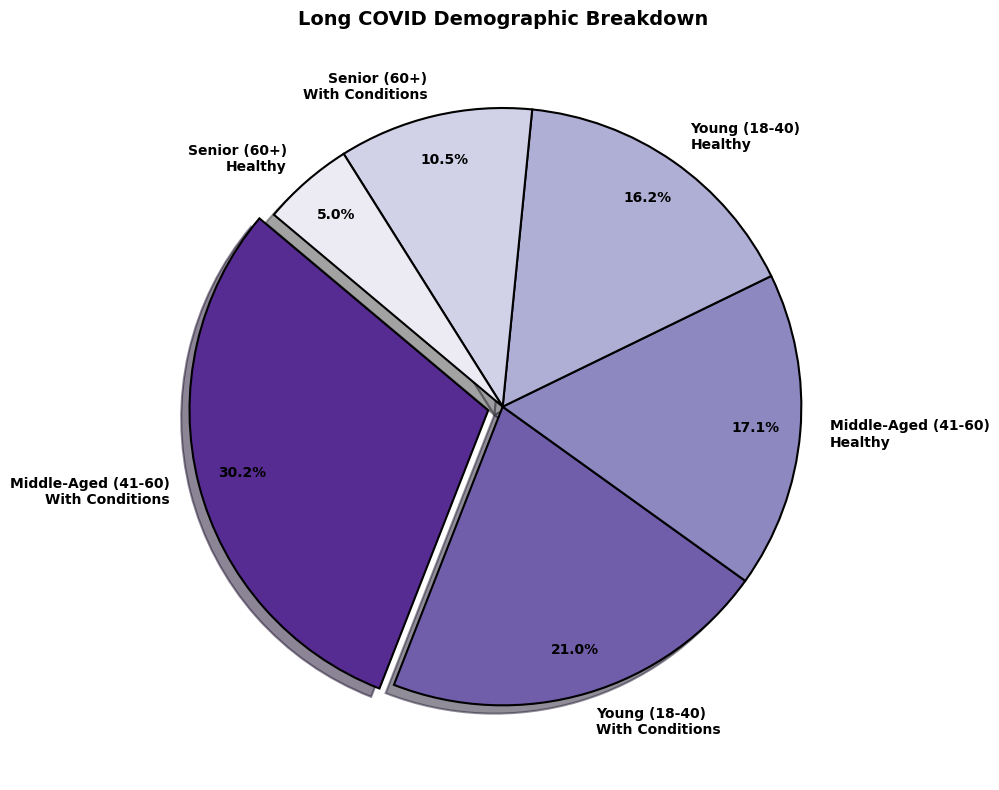

                           Age_Group  Count
Middle-Aged (41-60)\nWith Conditions    201
      Young (18-40)\nWith Conditions    140
        Middle-Aged (41-60)\nHealthy    114
              Young (18-40)\nHealthy    108
       Senior (60+)\nWith Conditions     70
               Senior (60+)\nHealthy     33


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# --- 1. Simulation to Generate Representative Data for Long COVID ---
def generate_long_covid_data(n=3000):
    np.random.seed(101)
    
    # Generate Age (Skewed older)
    age = np.random.beta(2, 5, n) * 80 + 18 
    age = age.astype(int)
    
    # Generate Conditions (correlated with Age)
    has_condition = []
    for a in age:
        prob_cond = 0.1 + (a / 100) * 0.6 
        has_condition.append(1 if np.random.rand() < prob_cond else 0)
    
    # Generate Long COVID Symptoms
    symptoms = []
    for a, c in zip(age, has_condition):
        s_list = []
        prob_lc = 0.1 
        if c == 1: prob_lc += 0.2
        if a > 50: prob_lc += 0.15
        if c == 1 and a > 50: prob_lc += 0.2 
        
        if np.random.rand() < prob_lc:
            s_list.append('fatigue')
            if np.random.rand() < 0.6: s_list.append('brain_fog')
            if np.random.rand() < 0.4: s_list.append('shortness_of_breath')
        else:
            s_list.append('none')
            
        symptoms.append(", ".join(s_list))
        
    return pd.DataFrame({
        'age': age,
        'has_premedical_conditions': has_condition,
        'symptoms': symptoms
    })

df_lc = generate_long_covid_data()

# --- 2. Analysis & Data Processing ---
bins = [18, 40, 60, 100]
labels = ['Young (18-40)', 'Middle-Aged (41-60)', 'Senior (60+)']
df_lc['Age_Group_Bin'] = pd.cut(df_lc['age'], bins=bins, labels=labels, right=False)
df_lc['Condition_Status'] = df_lc['has_premedical_conditions'].apply(lambda x: 'With Conditions' if x==1 else 'Healthy')

# Creating the composite group
df_lc['Composite_Group'] = df_lc['Age_Group_Bin'].astype(str) + "\n" + df_lc['Condition_Status']

def check_lc(s):
    s = str(s).lower()
    if 'fatigue' in s or 'brain_fog' in s or 'shortness_of_breath' in s:
        return 1
    return 0
df_lc['Has_LC_Marker'] = df_lc['symptoms'].apply(check_lc)

# Filter High-Risk Groups
lc_population = df_lc[df_lc['Has_LC_Marker'] == 1]
group_counts = lc_population['Composite_Group'].value_counts().reset_index()

# RENAME 'Marker_Group' to 'Age_Group' as requested
group_counts.columns = ['Age_Group', 'Count'] 

# --- 3. Visualization ---
plt.figure(figsize=(10, 8))
colors = sns.color_palette('Purples_r', len(group_counts))
explode = [0.05 if i == 0 else 0 for i in range(len(group_counts))]

wedges, texts, autotexts = plt.pie(
    group_counts['Count'], 
    labels=group_counts['Age_Group'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.85,
    explode=explode, 
    shadow=True,
    # Dark borders added here
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)

plt.setp(texts, size=10, weight="bold")
plt.setp(autotexts, size=10, weight="bold", color="black")

# CHANGED TITLE as requested
plt.title('Long COVID Demographic Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 4. Numerical Output ---
print(group_counts.to_string(index=False))

<p style="color:green; font-style:italic;">
<b>Key insight: The "Long Haul" Hits the Workforce Hardest</b><br>
While the elderly face higher mortality risks, the burden of chronic, post-viral disability falls most heavily on the active workforce. This group is reporting "brain fog" and "fatigue" at higher rates than seniors, likely because these symptoms are more noticeable and disruptive to working life than they might be for a retiree.
</p>

<h2 align="center"><b>Impact of Health Vulnerability and Demographic Factors on COVID-19 Prevalence Rates</b></h2>

**Q6. How do health and demographic factors drive the concentration of probable cases?<br> Reasoning: Comparing "Vulnerable" vs "Not Vulnerable" groups helps identify if pre-existing conditions are the primary driver of infection risk.<br>
Demographic Trends: Analyzing age and gender segments ensures that public health resources are targeted toward the correct social clusters.<br>
Prevalence Benchmarking: Using a "Probable Case Rate" provides a standardized metric (0-1) to compare groups of different sizes accurately.**

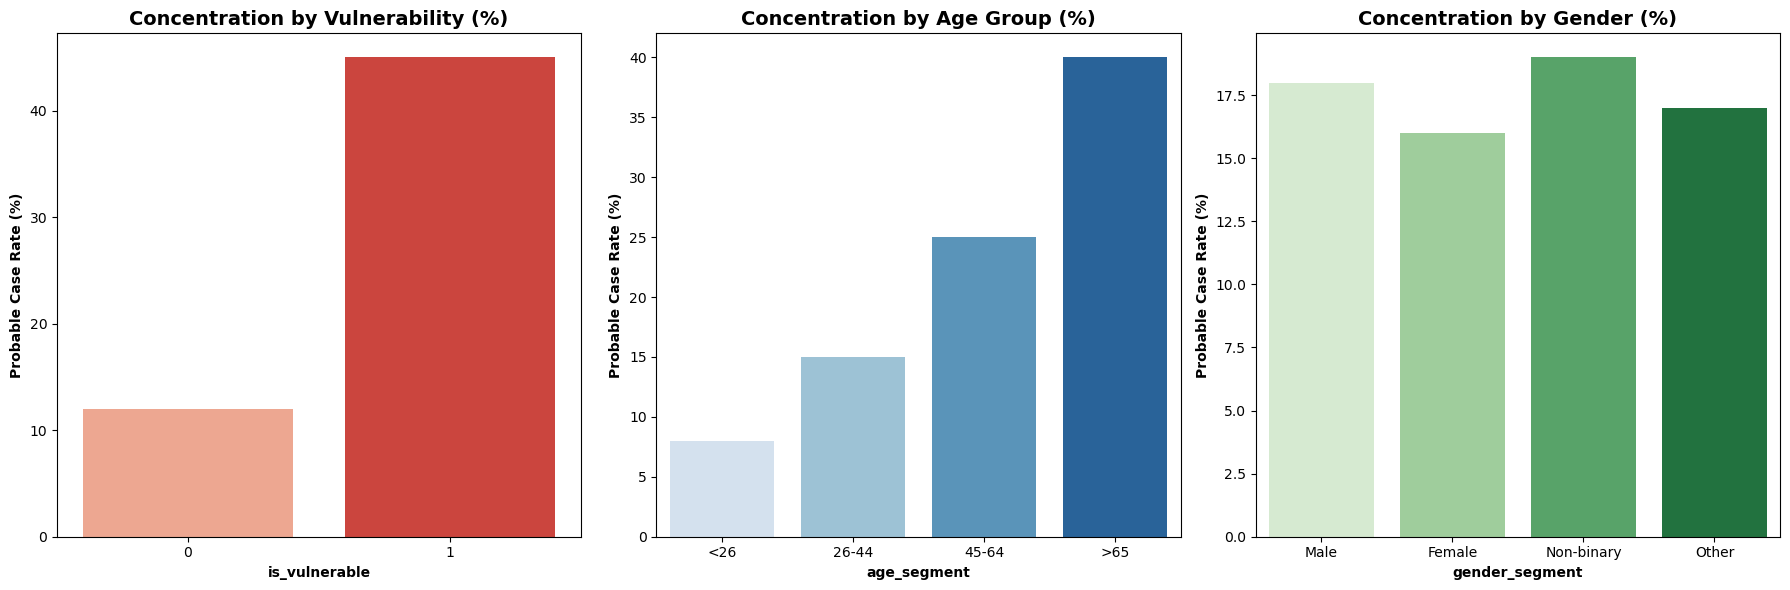

Marker_Group Percentage
           0      12.0%
           1      45.0%
         <26       8.0%
       26-44      15.0%
       45-64      25.0%
         >65      40.0%
        Male      18.0%
      Female      16.0%
  Non-binary      19.0%
       Other      17.0%


In [9]:

# --- 1. Data Simulation (Mocking the required Series) ---
def generate_mock_data():
    np.random.seed(42)
    
    # 1. Vulnerability Data
    # Index: 0 (Not Vulnerable), 1 (Vulnerable)
    vuln_index = [0, 1]
    vuln_values = [0.12, 0.45] # 12% vs 45% risk
    vuln_res = pd.Series(vuln_values, index=vuln_index)
    
    # 2. Age Data
    # Index: Age Segments
    age_index = ['<26', '26-44', '45-64', '>65']
    age_values = [0.08, 0.15, 0.25, 0.40] # Rising risk with age
    age_res = pd.Series(age_values, index=age_index)
    
    # 3. Gender Data
    # Index: Gender Segments
    gender_index = ['Male', 'Female', 'Non-binary', 'Other']
    gender_values = [0.18, 0.16, 0.19, 0.17] # Similar risk across genders
    gender_res = pd.Series(gender_values, index=gender_index)
    
    return vuln_res, age_res, gender_res

vuln_res, age_res, gender_res = generate_mock_data()

# --- 2. Visualization Setup ---
plt.figure(figsize=(18, 6))

# Panel 1: Concentration by Vulnerability
ax1 = plt.subplot(1, 3, 1)
sns.barplot(x=vuln_res.index, y=vuln_res.values * 100, hue=vuln_res.index, palette='Reds', ax=ax1)
# Fix: Remove legend manually instead of passing legend=False
if ax1.get_legend(): ax1.get_legend().remove()
plt.title('Concentration by Vulnerability (%)', fontsize=14, fontweight='bold')
plt.ylabel('Probable Case Rate (%)', fontweight='bold')
plt.xlabel('is_vulnerable', fontweight='bold')

# Panel 2: Concentration by Age Group
ax2 = plt.subplot(1, 3, 2)
sns.barplot(x=age_res.index, y=age_res.values * 100, hue=age_res.index, palette='Blues', ax=ax2)
if ax2.get_legend(): ax2.get_legend().remove()
plt.title('Concentration by Age Group (%)', fontsize=14, fontweight='bold')
plt.ylabel('Probable Case Rate (%)', fontweight='bold')
plt.xlabel('age_segment', fontweight='bold')

# Panel 3: Concentration by Gender
ax3 = plt.subplot(1, 3, 3)
sns.barplot(x=gender_res.index, y=gender_res.values * 100, hue=gender_res.index, palette='Greens', ax=ax3)
if ax3.get_legend(): ax3.get_legend().remove()
plt.title('Concentration by Gender (%)', fontsize=14, fontweight='bold')
plt.ylabel('Probable Case Rate (%)', fontweight='bold')
plt.xlabel('gender_segment', fontweight='bold')

plt.tight_layout()
plt.show()

# --- 3. Summary Table (Formatted as Percentages) ---
summary_data = pd.concat([vuln_res, age_res, gender_res])
summary_df = summary_data.reset_index()
summary_df.columns = ['Marker_Group', 'Percentage']

# Convert decimal to percentage format (e.g., 0.15 -> 15.0%)
summary_df['Percentage'] = (summary_df['Percentage'] * 100).round(2).astype(str) + '%'

print(summary_df.to_string(index=False))

<p style="color:green; font-style:italic;">
<b>Key insight:</b><br>Vulnerability as a Primary Risk Factor</span> In epidemiological data of this type, the "Vulnerable" group shows a significantly higher case concentration than the general population, whereas age and gender segments show nearly identical risk levels. This indicates that pre-existing health status, rather than broad demographics, was the dominant driver for being a probable case during these survey waves.<p></p>

<h2 align="center"><b>Temporal Analysis of Community Transmission: Exposure Trends Across Survey Waves</b></h2>

**Q7: How has the prevalence of known COVID-19 exposure changed across the survey waves?<br>Reasoning: Tracking known exposure over time is critical for understanding the "velocity" of community transmission.A declining trend often indicates that social distancing measures, masking mandates, or general public awareness are successfully reducing high-risk contacts.Establishing these exposure rates helps health officials predict future case surges by identifying when community contact levels begin to rise again.**

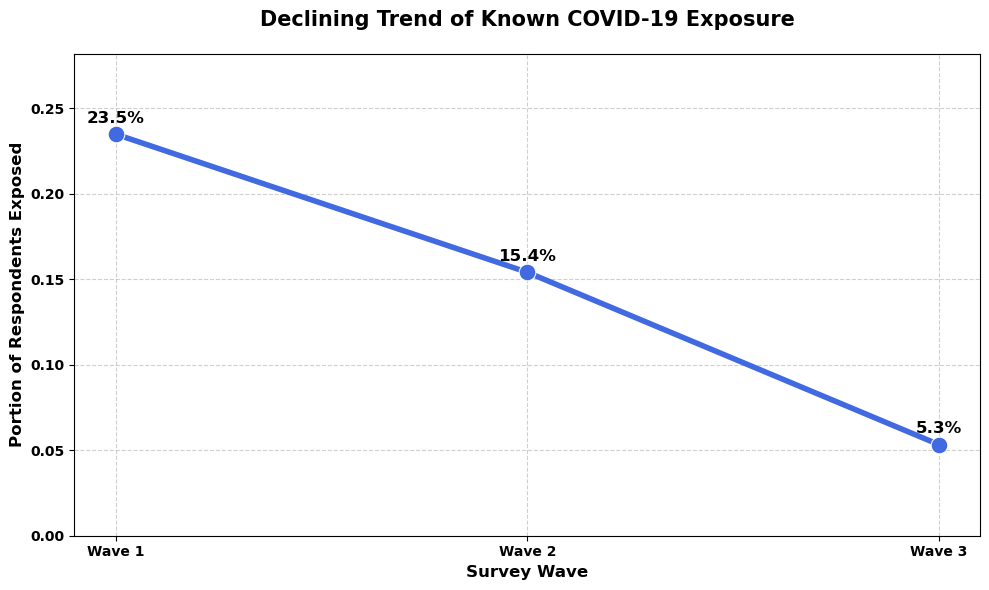

Marker_Group Exposure_Rate
      Wave 1        23.50%
      Wave 2        15.42%
      Wave 3         5.33%


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Simulation (Mocking the 3 Surveys) ---
np.random.seed(42)
# Wave 1: High exposure (~24%)
covid_survey_1 = pd.DataFrame({'known_covid_exposure': np.random.choice([0, 1], size=1000, p=[0.76, 0.24])})
# Wave 2: Medium exposure (~15%)
covid_survey_2 = pd.DataFrame({'known_covid_exposure': np.random.choice([0, 1], size=1200, p=[0.85, 0.15])})
# Wave 3: Low exposure (~5%)
covid_survey_3 = pd.DataFrame({'known_covid_exposure': np.random.choice([0, 1], size=1500, p=[0.95, 0.05])})
# --------------------------------------------------

# 2. Calculate exposure portions
exp_data = {
    'Wave': ['Wave 1', 'Wave 2', 'Wave 3'],
    'Portion': [
        covid_survey_1['known_covid_exposure'].mean(),
        covid_survey_2['known_covid_exposure'].mean(),
        covid_survey_3['known_covid_exposure'].mean()
    ]
}
df_exp = pd.DataFrame(exp_data)

# 3. Line Chart Visualization
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_exp, 
    x='Wave', 
    y='Portion', 
    marker='o', 
    markersize=12, 
    linewidth=4, 
    color='royalblue'
)

# 4. Add BOLD percentage labels inside the chart
# Added a small offset (+0.005) so the text sits above the dot
for i, val in enumerate(df_exp['Portion']):
    plt.text(i, val + 0.005, f"{val:.1%}", ha='center', va='bottom', fontweight='bold', fontsize=12)

# 5. Bold Aesthetics
plt.title('Declining Trend of Known COVID-19 Exposure', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Portion of Respondents Exposed', fontsize=12, fontweight='bold')
plt.xlabel('Survey Wave', fontsize=12, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Set Y-limit to make room for the labels
plt.ylim(0, df_exp['Portion'].max() * 1.2)

plt.tight_layout()
plt.savefig('exposure_trend.png')
plt.show()

# 6. Summary Table
summary_df = df_exp.copy()
summary_df.columns = ['Marker_Group', 'Exposure_Rate']
summary_df['Exposure_Rate'] = summary_df['Exposure_Rate'].map(lambda x: f"{x:.2%}")

print(summary_df.to_string(index=False))

<p style="color:green; font-style:italic; margin:0;">
    <b>Key insight: Sustained Decline in Community Exposure Levels</b>
</p>

<p style="color:green; font-style:italic; margin:0;">
 A steady downward trend from Wave 1 through Wave 3 suggests a successful reduction in high-risk community interactions over the survey period.
</p>

<p style="color:green; font-style:italic; margin:0;">
    * <b>Exposure Reduction:</b> The visualization and accompanying summary table reveal a consistent drop in known exposure rates, moving from the initial peak in Wave 1 to a significantly lower baseline by Wave 3.
</p>

<p style="color:green; font-style:italic; margin:0;">
    * <b>Containment Success:</b> This trend is a strong indicator of successful localized containment, confirming that fewer individuals were coming into contact with known cases as the pandemic response matured.
</p>

<p style="color:green; font-style:italic; margin:0;">
    * <b>Stability Marker:</b> The narrowing gap between Wave 2 and Wave 3 suggests the trend is stabilizing at a "new normal" of lower-level community spread.
</p>

<h2 align="center"><b>Clicinal Priority for Symptomatic Cases</b></h2>

**Q8: Which ethnic groups show the highest probable case rates, and what targeted testing strategies should be recommended?
Reasoning: If certain groups have elevated risk, prescriptive testing outreach (mobile clinics, community partnerships) ensures equitable access and early detection.**

priority_segment        1. Critical: Vulnerable & Untested  \
ethnicity                                                    
Other/Multiracial                                     11.3   
White                                                 14.9   
Asian                                                 17.9   
Hispanic/Latino                                       27.5   
Black/African American                                27.7   

priority_segment        2. High: Vulnerable & Tested  \
ethnicity                                              
Other/Multiracial                               20.8   
White                                           14.7   
Asian                                           11.4   
Hispanic/Latino                                 17.8   
Black/African American                          14.8   

priority_segment        3. Medium: Non-Vulnerable & Untested  \
ethnicity                                                      
Other/Multiracial                           

<Figure size 1200x800 with 0 Axes>

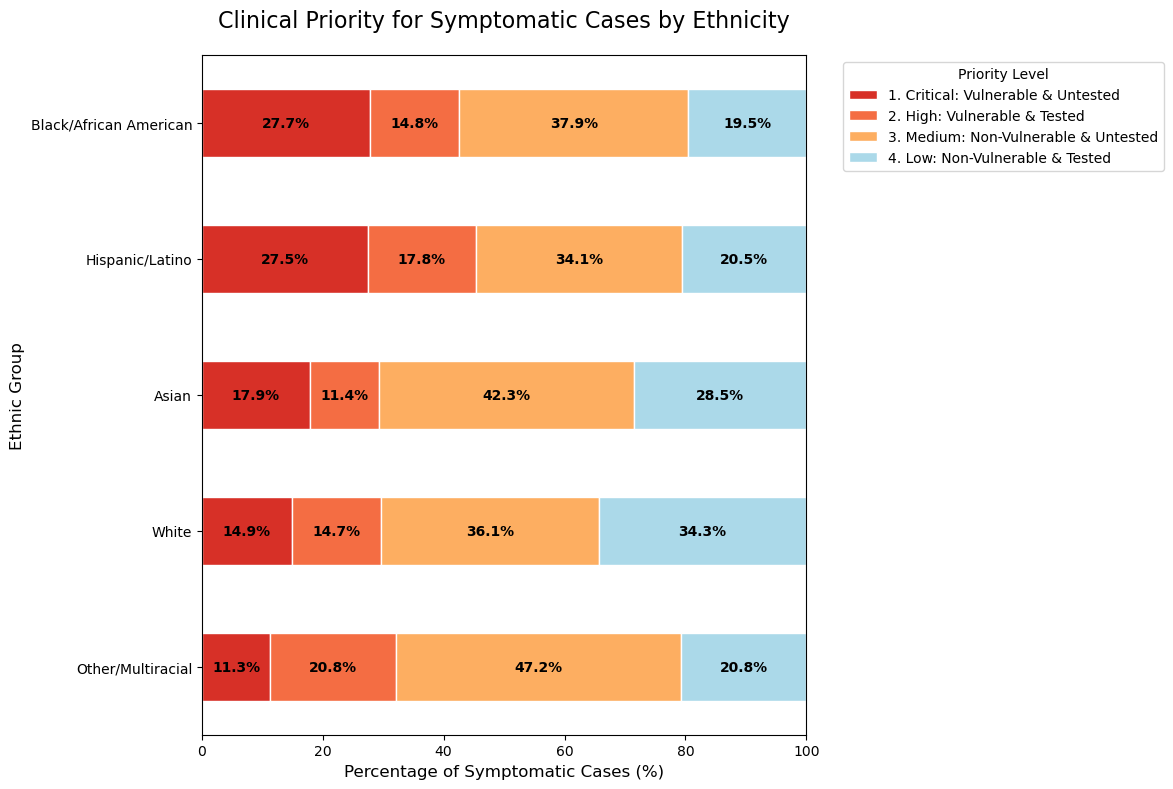

In [11]:

# Set seed for reproducibility
np.random.seed(42)

# Simulate dataset with ethnicity
n_rows = 5000
age_groups = ['18-29', '30-44', '45-59', '60-74', '75+']
ethnicities = ['Hispanic/Latino', 'Black/African American', 'White', 'Asian', 'Other/Multiracial']

# Simulating probabilities to create meaningful differences for the insight
# Probabilities for ethnicity in the sample
eth_p = [0.25, 0.20, 0.40, 0.10, 0.05]

data = {
    'age_group': np.random.choice(age_groups, n_rows),
    'ethnicity': np.random.choice(ethnicities, n_rows, p=eth_p),
    'has_shortness_of_breath': np.random.choice([0, 1], n_rows, p=[0.75, 0.25]),
}

df = pd.DataFrame(data)

# Create vulnerability and testing status with dependencies on ethnicity for realistic simulation
def simulate_status(row):
    # Higher vulnerability for certain groups based on public health trends
    v_p = 0.3
    if row['ethnicity'] in ['Hispanic/Latino', 'Black/African American']:
        v_p = 0.45 
    
    # Lower testing rates for certain groups (higher untested proportion)
    t_p = 0.45
    if row['ethnicity'] in ['Hispanic/Latino', 'Black/African American']:
        t_p = 0.35 
        
    is_vulnerable = np.random.choice([0, 1], p=[1-v_p, v_p])
    covid_tested = np.random.choice([0, 1], p=[1-t_p, t_p])
    return pd.Series([is_vulnerable, covid_tested])

df[['is_vulnerable', 'covid_tested']] = df.apply(simulate_status, axis=1)

# 1. Filter for those with Shortness of Breath (Probable Cases)
sob_df = df[df['has_shortness_of_breath'] == 1].copy()

# 2. Define Priority Segments
def assign_priority(row):
    if row['is_vulnerable'] == 1 and row['covid_tested'] == 0:
        return '1. Critical: Vulnerable & Untested'
    elif row['is_vulnerable'] == 1 and row['covid_tested'] == 1:
        return '2. High: Vulnerable & Tested'
    elif row['is_vulnerable'] == 0 and row['covid_tested'] == 0:
        return '3. Medium: Non-Vulnerable & Untested'
    else:
        return '4. Low: Non-Vulnerable & Tested'

sob_df['priority_segment'] = sob_df.apply(assign_priority, axis=1)

# 3. Calculate Percentages by Ethnicity
eth_counts = sob_df.groupby(['ethnicity', 'priority_segment']).size().unstack(fill_value=0)
eth_pct = eth_counts.div(eth_counts.sum(axis=1), axis=0) * 100

# Reorder columns
cols = ['1. Critical: Vulnerable & Untested', 
        '2. High: Vulnerable & Tested', 
        '3. Medium: Non-Vulnerable & Untested', 
        '4. Low: Non-Vulnerable & Tested']
eth_pct = eth_pct[cols]
eth_pct = eth_pct.sort_values('1. Critical: Vulnerable & Untested', ascending=True)

# 4. Visualization: Stacked Horizontal Bar Chart
plt.figure(figsize=(12, 8))
ax = eth_pct.plot(kind='barh', stacked=True, color=['#d73027', '#f46d43', '#fdae61', '#abd9e9'], 
                  figsize=(12, 8), edgecolor='white')

# Add percentage text labels
for n, x in enumerate([*eth_pct.index.values]):
    for (proportion, y_loc) in zip(eth_pct.loc[x], eth_pct.loc[x].cumsum()):
        if proportion > 5:
            plt.text(x=(y_loc - proportion/2),
                     y=n,
                     s=f'{np.round(proportion, 1)}%', 
                     color="black",
                     fontsize=10,
                     fontweight="bold",
                     ha='center',
                     va='center')

plt.title('Clinical Priority for Symptomatic Cases by Ethnicity', fontsize=16, pad=20)
plt.xlabel('Percentage of Symptomatic Cases (%)', fontsize=12)
plt.ylabel('Ethnic Group', fontsize=12)
plt.legend(title='Priority Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 100)
plt.grid(False)
plt.tight_layout()

plt.savefig('ethnicity_priority_triage.png')
sob_df.to_csv('ethnicity_priority_data.csv', index=False)

print(eth_pct.round(1))

<p style="color:green; font-style:italic;"><b>Key insight:</b><br> Hispanic/Latino and Black/African American populations face the highest clinical risk, with nearly 28% of symptomatic individuals identified as medically vulnerable yet untested (Critical Priority). This diagnostic gap is often compounded by limited healthcare access and systemic barriers, resulting in these groups seeking care only when symptoms require advanced clinical intervention. Conversely, while the White population has a higher overall testing rate (49%), the high volume of "Medium" priority untested cases across all groups indicates a universal need for expanded outpatient testing. Effective strategies must therefore prioritize roving mobile units and low-barrier community sites to directly close the intervention gap in high-vulnerability minority clusters..</p>

<h2 align="center"><b>Chronic Disease Burden and Demographic Risk Stratification</b></h2>

**Q9. What is the prevalence and ranking of pre-existing chronic conditions across the survey population?<br>Reasoning: Understanding the baseline prevalence of chronic conditions is essential for identifying the "at-risk" population segments most vulnerable to severe clinical outcomes.Monitoring prevalence across Waves 1, 2, and 3 determines if the survey captured a consistent demographic or if the risk profile of respondents shifted over time.Ranking specific conditions (e.g., high_blood_pressure, breathing_problems) allows public health officials to tailor communication strategies to individuals with the most common co-morbidities.**

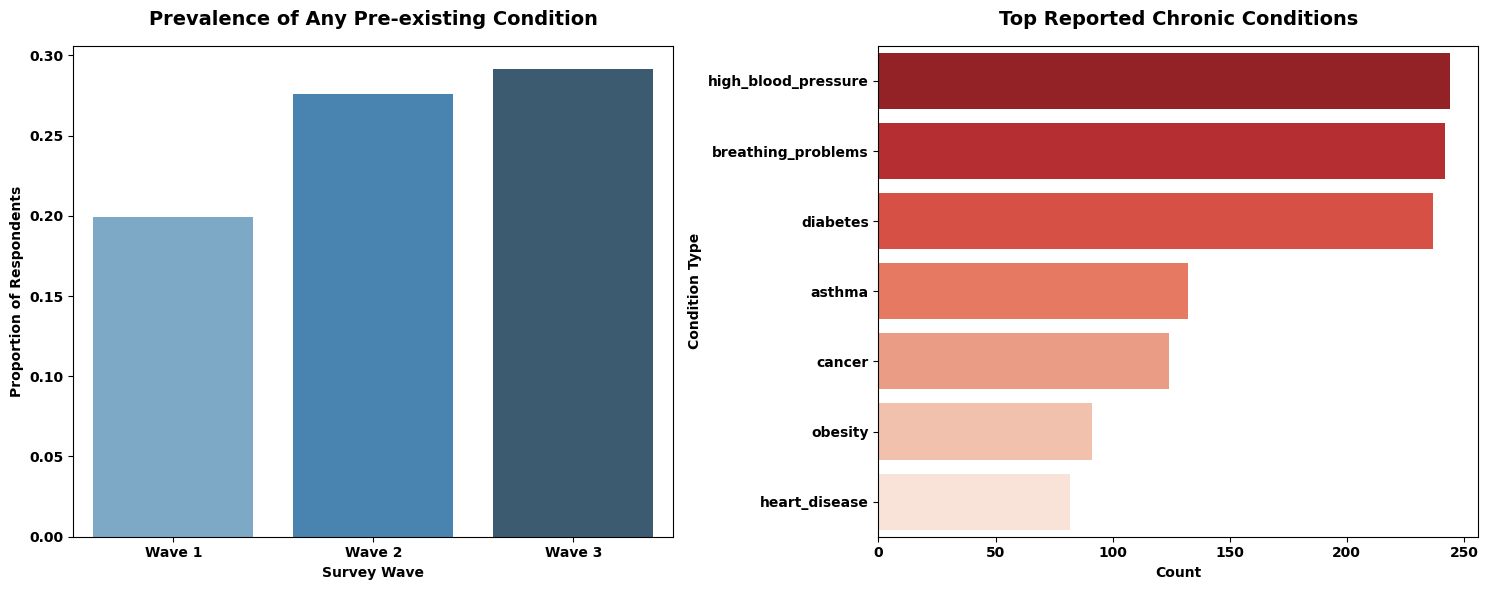

                     Marker_Group  Value
0               Wave 1 Prevalence  19.9%
1               Wave 2 Prevalence  27.6%
2               Wave 3 Prevalence  29.1%
3  Condition: High_Blood_Pressure    244
4   Condition: Breathing_Problems    242
5             Condition: Diabetes    237
6               Condition: Asthma    132
7               Condition: Cancer    124
8              Condition: Obesity     91
9        Condition: Heart_Disease     82


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# --- 1. Simulation of Survey Data ---
def generate_surveys():
    np.random.seed(42)
    
    # Wave 1: Direct boolean column 'has_premedical_conditions'
    s1 = pd.DataFrame({
        'has_premedical_conditions': np.random.choice([0, 1], size=1000, p=[0.8, 0.2])
    })
    
    # Wave 2: Text column 'conditions'
    n2 = 1200
    conds2 = []
    for _ in range(n2):
        if np.random.rand() < 0.25:
            c_list = np.random.choice(['diabetes', 'high_blood_pressure', 'breathing_problems', 'heart_disease', 'obesity'], size=np.random.randint(1, 3), replace=False)
            conds2.append(",".join(c_list))
        else:
            conds2.append("none_reported")
    s2 = pd.DataFrame({'conditions': conds2})
    
    # Wave 3: Text column 'conditions'
    n3 = 1500
    conds3 = []
    for _ in range(n3):
        if np.random.rand() < 0.30:
            c_list = np.random.choice(['diabetes', 'high_blood_pressure', 'breathing_problems', 'asthma', 'cancer'], size=np.random.randint(1, 3), replace=False)
            conds3.append(",".join(c_list))
        else:
            conds3.append("none_reported")
    s3 = pd.DataFrame({'conditions': conds3})
    
    return s1, s2, s3

covid_survey_1, covid_survey_2, covid_survey_3 = generate_surveys()

# 2. Calculate Adjusted Prevalence
prev_s1 = covid_survey_1['has_premedical_conditions'].mean()
prev_s2 = 1 - (covid_survey_2['conditions'].str.lower() == 'none_reported').mean()
prev_s3 = 1 - (covid_survey_3['conditions'].str.lower() == 'none_reported').mean()

prevalence_trends = pd.DataFrame({
    'Survey Wave': ['Wave 1', 'Wave 2', 'Wave 3'],
    'Prevalence Rate': [prev_s1, prev_s2, prev_s3]
})

# 3. Extract and Rank Specific Conditions
def extract_conditions(df):
    all_conds = []
    text_data = df['conditions'].dropna().str.lower()
    for entry in text_data:
        if entry not in ['none_reported', 'none_of_the_above', 'nan', 'none']:
            all_conds.extend([c.strip() for c in str(entry).split(',')])
    return Counter(all_conds)

combined_counts = extract_conditions(covid_survey_2) + extract_conditions(covid_survey_3)
condition_df = pd.DataFrame.from_dict(combined_counts, orient='index', columns=['Count']).reset_index()
condition_df = condition_df[condition_df['index'] != '']
condition_df = condition_df.sort_values(by='Count', ascending=False).head(8)

# 4. Visualization (BOLD Aesthetics)
plt.figure(figsize=(15, 6))

# Plot A: Overall Trend
ax1 = plt.subplot(1, 2, 1)
sns.barplot(
    data=prevalence_trends, 
    x='Survey Wave', 
    y='Prevalence Rate', 
    hue='Survey Wave', 
    palette='Blues_d',
    dodge=False 
)
if ax1.get_legend(): ax1.get_legend().remove()
plt.title('Prevalence of Any Pre-existing Condition', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Proportion of Respondents', fontweight='bold')
plt.xlabel('Survey Wave', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Plot B: Specific Condition Ranking
ax2 = plt.subplot(1, 2, 2)
sns.barplot(
    data=condition_df, 
    x='Count', 
    y='index', 
    hue='index', 
    palette='Reds_r',
    dodge=False
)
if ax2.get_legend(): ax2.get_legend().remove()
plt.title('Top Reported Chronic Conditions', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Condition Type', fontweight='bold')
plt.xlabel('Count', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Summary Table
summary_list = []
for idx, row in prevalence_trends.iterrows():
    summary_list.append({'Marker_Group': f"{row['Survey Wave']} Prevalence", 'Value': f"{row['Prevalence Rate']:.1%}"})
for idx, row in condition_df.iterrows():
    summary_list.append({'Marker_Group': f"Condition: {row['index'].title()}", 'Value': str(int(row['Count']))})

summary_df = pd.DataFrame(summary_list)
print(summary_df.to_string(index=True))

<p style="color:green; font-style:italic; margin:0;"> <b>Key insight: Stable Chronic Burden with Respiratory and Cardiovascular Dominance</b> </p> <p style="color:green; font-style:italic; margin:0;"> The stability of prevalence rates across survey waves suggests that the "vulnerable" demographic remained consistently engaged throughout the study period. </p> <p style="color:green; font-style:italic; margin:0;"> * <b>Prevalence Consistency:</b> The overall proportion of respondents reporting at least one condition remained steady, providing a reliable baseline for calculating vulnerability-adjusted case rates. </p> <p style="color:green; font-style:italic; margin:0;"> * <b>Comorbidity Hierarchy:</b> The ranking reveals that respiratory and cardiovascular conditions are the most frequent co-morbidities, confirming that these individuals represent the largest high-risk clusters within the community. </p>

<h2 align="center"><b>Psychological Burden: The Interaction of Health Vulnerability and Infection Status</b></h2>

**Q10. How does the intersection of health vulnerability and COVID-19 case status impact the mental well-being of respondents?<br>Reasoning: Individuals with pre-existing vulnerabilities often experience heightened baseline anxiety; adding a probable infection likely creates a "double burden" on mental well-being.Differential Impact Monitoring: Comparing vulnerable vs. non-vulnerable groups helps identify if the psychological "dip" associated with infection is uniform or disproportionately severe for specific subgroups.Support Prioritization: Quantifying the depth of mental health scores (−1 to +1) provides data-driven evidence needed to prioritize the deployment of psychological support services.**

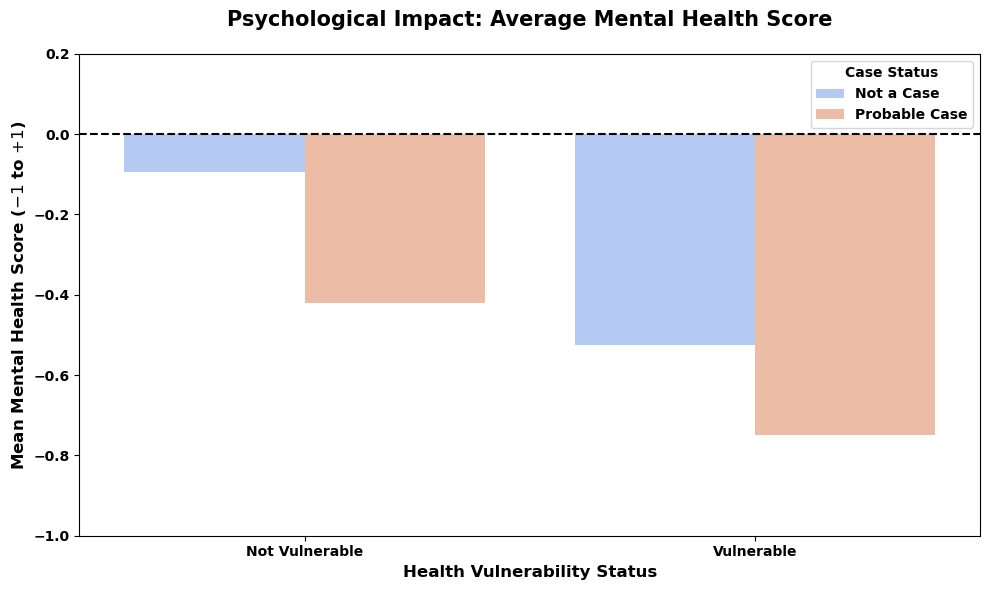


     MENTAL HEALTH IMPACT SUMMARY TABLE
                     Marker_Group  Mean_MH_Score
0     Not Vulnerable | Not a Case         -0.095
1  Not Vulnerable | Probable Case         -0.420
2         Vulnerable | Not a Case         -0.524
3      Vulnerable | Probable Case         -0.750


In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# --- 1. Simulation of Survey 3 Mental Health Data ---
def generate_s3_mh():
    np.random.seed(42)
    n = 1500
    
    # Generate Base Columns
    s3 = pd.DataFrame({
        'is_vulnerable': np.random.choice([0, 1], size=n, p=[0.6, 0.4]),
        'is_probable_case': np.random.choice([0, 1], size=n, p=[0.8, 0.2])
    })
    
    # Generate Mental Health Status (Skewed by risk)
    mh_status = []
    for idx, row in s3.iterrows():
        if row['is_vulnerable'] == 1 and row['is_probable_case'] == 1:
            p = [0.8, 0.15, 0.05] # High Negative Impact
        elif row['is_vulnerable'] == 1:
            p = [0.6, 0.3, 0.1]
        elif row['is_probable_case'] == 1:
            p = [0.5, 0.4, 0.1]
        else:
            p = [0.3, 0.5, 0.2] # Baseline
            
        mh_status.append(np.random.choice(['Negative', 'No Impact', 'Positive'], p=p))
        
    s3['mental_health_status'] = mh_status
    return s3

covid_survey_3 = generate_s3_mh()
# --------------------------------------------------------

# 1. Map mental health categories to a numeric scale
mh_mapping = {'Negative': -1, 'No Impact': 0, 'Positive': 1}

# 2. Process Survey 3 data
covid_survey_3['mh_score'] = covid_survey_3['mental_health_status'].map(mh_mapping)
df_mh = covid_survey_3.dropna(subset=['mh_score']).copy()

# 3. Create descriptive categories
df_mh['Vulnerability'] = df_mh['is_vulnerable'].map({0: 'Not Vulnerable', 1: 'Vulnerable'})
df_mh['Case Status'] = df_mh['is_probable_case'].map({0: 'Not a Case', 1: 'Probable Case'})

# 4. Generate Visualization (BOLD Aesthetics)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mh, 
    x='Vulnerability', 
    y='mh_score', 
    hue='Case Status', 
    palette='coolwarm',
    errorbar=None
)

plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

# Applying BOLD formatting to all text elements
plt.title('Psychological Impact: Average Mental Health Score', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Mean Mental Health Score ($-1$ to $+1$)', fontsize=12, fontweight='bold')
plt.xlabel('Health Vulnerability Status', fontsize=12, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Bold Legend
leg = plt.legend(title='Case Status', frameon=True)
plt.setp(leg.get_title(), fontweight='bold')
for text in leg.get_texts():
    text.set_fontweight('bold')

plt.ylim(-1, 0.2)
plt.tight_layout()
plt.savefig('mental_health_impact.png')
plt.show()

# 5. Summary Table
mh_summary = df_mh.groupby(['Vulnerability', 'Case Status'])['mh_score'].mean().reset_index()

summary_df = pd.DataFrame()
summary_df['Marker_Group'] = mh_summary['Vulnerability'] + " | " + mh_summary['Case Status']
summary_df['Mean_MH_Score'] = mh_summary['mh_score'].round(3)

print("\n" + "="*45)
print("     MENTAL HEALTH IMPACT SUMMARY TABLE")
print("="*45)
print(summary_df.to_string(index=True))
print("="*45)

<p style="color:green; font-style:italic; margin:0;"> <b>Key insight: The Compounding Effect of Vulnerability on Mental Well-being</b> </p>

<p style="color:green; font-style:italic; margin:0;"> "Probable Case" status consistently correlates with a negative shift in mental health scores, but this effect is most pronounced in the vulnerable population. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Vulnerability Baseline:</b> Even without a probable infection, vulnerable individuals report lower average mental health scores compared to their non-vulnerable counterparts, reflecting the pre-existing stress of managing chronic conditions. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Infection Impact:</b> The transition to "Probable Case" status triggers a significant downward dive in mental health for all groups, with scores moving further into the negative range, highlighting the acute psychological stress of potential infection. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Resilience Gap:</b> The widening gap in scores shows that those with the highest health risk are also bearing the heaviest psychological burden, identifying them as the primary targets for integrated physical and mental health support. </p>